In [6]:
import matplotlib.pyplot as plt
import scienceplots
plt.style.use(['science', 'nature', 'grid'])

from matplotlib.lines import Line2D
import matplotlib.ticker as ticker

import string
import numpy as np
from scipy.interpolate import interp1d
import pandas as pd

from LoadTSV import read_solution_file, interpolate_solution, sol_final

In [7]:
WIDTH = 6.0 
HEIGHT = 5.0

plt.rcParams.update({
    "figure.figsize": (WIDTH, .5*HEIGHT),
    "font.size": 10,           # Matches thesis 10pt
    "axes.labelsize": 10,
    "legend.fontsize": 8,      # Slightly smaller for legends
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "lines.linewidth": 1,
    "lines.markersize": 4,
    "savefig.bbox": 'tight',   # Ensures no labels are cut off
    "savefig.pad_inches": 0.05
})

In [8]:
# Setup
# Solver and simulation parameters
closure = "ExtGram"
Kn = 1.0
source = "relaxation_source"
T_end = 0.3
base_tree_level_vec = [6, 7, 8, 9, 10, 11, 12, 14]
polydeg = 1

# Initial condition parameters
rho_0 = 1.0
v_0 = 0.0
theta_0 = 1.0
epsilon = 0.01
k = 0.5

In [9]:
colors = ['blue', 'red', 'green', 'orange', 'purple']
marker = ['-o', '-x', '-p', '-^', '-<', '-v']
marker_legend = ['o', 'x', 'p', '^', '<', 'v']

<>:64: SyntaxWarning: invalid escape sequence '\m'
<>:73: SyntaxWarning: invalid escape sequence '\m'
<>:64: SyntaxWarning: invalid escape sequence '\m'
<>:73: SyntaxWarning: invalid escape sequence '\m'
/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_36922/3464675149.py:64: SyntaxWarning: invalid escape sequence '\m'
  axs[i].loglog(Nx, slope2, 'k-.', alpha=0.5, label='$\mathcal{O}(N_x^2)$')
/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_36922/3464675149.py:73: SyntaxWarning: invalid escape sequence '\m'
  moment_elements.append(Line2D([0], [0], color='k', linestyle='--', label='$\mathcal{O}(N_x)$'))
/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_36922/3464675149.py:85: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


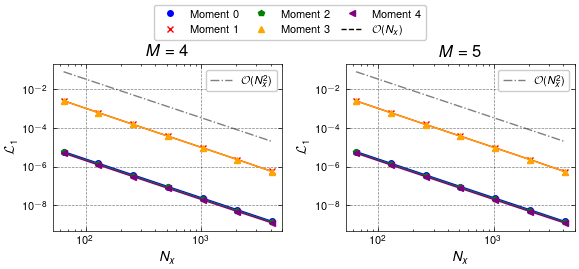

In [11]:
Moments = [4, 5]
source_string = 'relaxation_source'

fig, axs = plt.subplots(1, 2)

for i, M in enumerate(Moments):
    moment_solutions = []
    x_solutions = []
    
    for base_tree_level in base_tree_level_vec:
        filename = f"../out/GridConvergencePeriodic/moments_solution_M{M}_closure{closure}_Kn{Kn}_T_end{T_end}_rho_0{rho_0}_v_0{v_0}_theta_0{theta_0}_epsilon{epsilon}_k{k}_base_tree_level{base_tree_level}_polydeg{polydeg}_cons.tsv"
        
        data = read_solution_file(filename)

        # Build time → timestep mapping
        times = np.array([data[ts]["t"] for ts in sorted(data.keys())])
        timesteps = np.array(sorted(data.keys()))

        time_query = 21 # last time step
        sol = interpolate_solution(data, time_query, times, timesteps)
        x, u, t = sol["x"], sol["u"], sol["t"]

        
        x_solutions.append(x)
        moment_solutions.append(u)  # Store all moments

        rho = u[:, 0]
        v = u[:, 1] / rho
        p = u[:, 2] - rho * v**2

    errors = {}
    Nx = []
    for mom in range(M+1):
        errors[mom] = []
        ref_solution = interp1d(x_solutions[-1], moment_solutions[-1][:, mom])  # Using the same data as reference for simplicity
        for j, tree_level in enumerate(base_tree_level_vec[:-1]):
            data_trixi = moment_solutions[j][:, mom]
            trixi_solution = interp1d(x_solutions[j], data_trixi, kind='linear', fill_value="extrapolate") # ! cubic
            
            diff = ref_solution(x_solutions[-1]) - trixi_solution(x_solutions[-1])
            # error = np.sqrt(np.mean(diff**2)) / np.sqrt(np.mean(ref_solution(x_solutions[-1])**2))
            error = np.linalg.norm(diff, 2) / np.linalg.norm(ref_solution(x_solutions[-1]), 2)
            # error = np.mean(np.abs(diff)) / np.mean(np.abs(ref_solution(x_solutions[-1])))
            errors[mom].append(error)
            if mom == 0:
                Nx.append(2**tree_level) 

    for mom in range(5):
        axs[i].loglog(Nx, errors[mom], marker=marker_legend[mom], color=colors[mom])


    # --- Add Reference Slopes ---
    # Calculate dummy lines based on the last data point of Moment 0
    Nx = np.array(Nx)
    ref_y = np.array(errors[0][-1])
    ref_x_last = Nx[-1]

    # # Slope 1: O(N^-1)
    # slope1 = (ref_y) / (Nx / ref_x_last)
    # axs[i].loglog(Nx, slope1, 'k--', alpha=0.5, label='$\mathcal{O}(N_x)$')
    
    # Slope 2: O(N^-2)
    slope2 = (ref_y + 0.2e-4) / (Nx / ref_x_last)**2
    axs[i].loglog(Nx, slope2, 'k-.', alpha=0.5, label='$\mathcal{O}(N_x^2)$')

    axs[i].legend()

    axs[i].set_xlabel('$N_x$')
    axs[i].set_ylabel('$\\mathcal{L}_1$')
    axs[i].set_title(f'$M={M}$')

moment_elements = [Line2D([0], [0], color=colors[mom], marker=marker_legend[mom], label=f'Moment {mom}', linestyle='') for mom in range(5)]
moment_elements.append(Line2D([0], [0], color='k', linestyle='--', label='$\mathcal{O}(N_x)$'))
fig.legend(
    handles=moment_elements, 
    loc='upper center', 
    bbox_to_anchor=(0.5, 1.12), 
    ncol=3, 
    # frameon=True,
    columnspacing=1.0 # Adjust spacing between columns
)

fig.tight_layout()
fig.savefig(f'../out/Figures/Riemann1D/GridConvergencePeriodic_M4M5.pdf', bbox_inches='tight')
fig.show()